<a href="https://colab.research.google.com/github/AlmasMalik66/DataScience-AI-Assignments/blob/main/Week8/Unsupervised_Learning_%E2%80%93K_Means%20%26%20PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 8: Unsupervised Learning – K-Means & PCA**



**Step 1: Import Libraries**

In [1]:
# Step 1: Import Required Libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


**Step 2: Load and Prepare Data**

In [3]:
import pandas as pd

# --- Load datasets safely ---
# Skip problematic lines if any exist in CSV
df_fake = pd.read_csv("Fake.csv", on_bad_lines='skip')
df_true = pd.read_csv("True.csv", on_bad_lines='skip')

print("Fake news shape:", df_fake.shape)
print("True news shape:", df_true.shape)

# --- Assign labels (for reference only, not used in clustering) ---
df_fake['label'] = 1
df_true['label'] = 0

# --- Combine both datasets ---
df = pd.concat([df_fake, df_true], ignore_index=True)

# --- Create one combined text column ---
df['combined_text'] = df['title'] + " " + df['text']

# --- Drop missing rows (if any) ---
df = df.dropna(subset=['combined_text'])

print("Combined dataset shape:", df.shape)
df.head(3)



Fake news shape: (23481, 4)
True news shape: (21417, 4)
Combined dataset shape: (44898, 6)


,title,text,subject,date,label,combined_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1,Sheriff David Clarke Becomes An Internet Joke...


**Step 3: TF-IDF Vectorization**

In [4]:
# Convert text data to numerical format using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
X_tfidf = vectorizer.fit_transform(df['combined_text'])

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (44898, 2000)


**Step 4: Apply K-Means Clustering**

In [5]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_tfidf)

# Add cluster labels to the dataframe
df['cluster'] = kmeans.labels_

# Show first few rows with assigned clusters
df[['label', 'cluster', 'title']].head(10)


,label,cluster,title
0,1,1,Donald Trump Sends Out Embarrassing New Year’...
1,1,1,Drunk Bragging Trump Staffer Started Russian ...
2,1,0,Sheriff David Clarke Becomes An Internet Joke...
3,1,1,Trump Is So Obsessed He Even Has Obama’s Name...
4,1,0,Pope Francis Just Called Out Donald Trump Dur...
5,1,0,Racist Alabama Cops Brutalize Black Boy While...
6,1,1,"Fresh Off The Golf Course, Trump Lashes Out A..."
7,1,1,Trump Said Some INSANELY Racist Stuff Inside ...
8,1,1,Former CIA Director Slams Trump Over UN Bully...
9,1,1,WATCH: Brand-New Pro-Trump Ad Features So Muc...


**Step 5: Apply PCA for 2D Visualization**

In [6]:
# Reduce dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

# Store PCA components
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

df[['PCA1', 'PCA2', 'cluster']].head()


,PCA1,PCA2,cluster
0,0.081531,-0.037570,1
1,0.225151,0.070373,1
2,-0.005972,-0.134483,0
3,0.155050,-0.021573,1
4,-0.000806,0.007828,0


**Step 6 : Visualize Clusters in 2D**

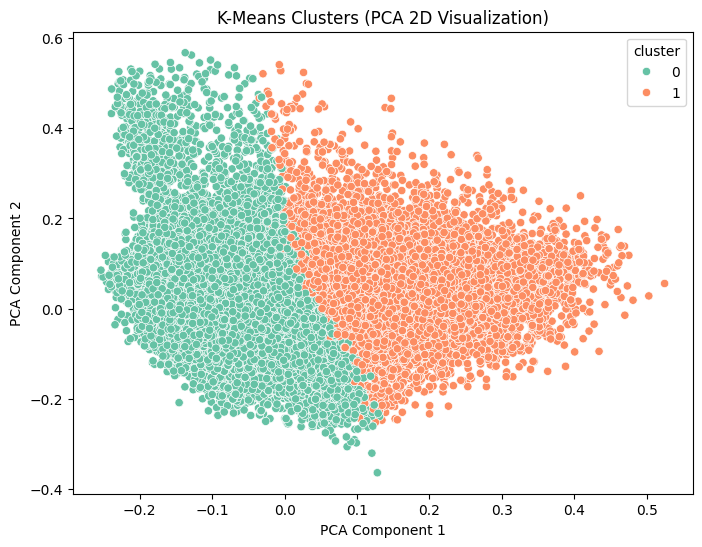

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df, palette='Set2')
plt.title("K-Means Clusters (PCA 2D Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


# **Apply Clustering on Dataset**

**Step 7: Analyze Clusters Centers**



In [13]:
# Step 7: Analyze Cluster Centers – Top Words per Cluster
import numpy as np
n_clusters = 2

terms = vectorizer.get_feature_names_out()

for i in range(n_clusters):
    print(f"\nCluster {i} top words:")
    cluster_center = kmeans.cluster_centers_[i]
    top_indices = cluster_center.argsort()[-10:][::-1]
    top_words = [terms[ind] for ind in top_indices]
    print(", ".join(top_words))



Cluster 0 top words:
said, state, obama, government, people, president, reuters, police, video, clinton

Cluster 1 top words:
trump, president, said, donald, clinton, campaign, republican, white, house, video


**Insights:**

* Cluster 0: Represents general political or real news content (mentions like “state”, “government”, “police”).
* Cluster 1: Represents fake or campaign-related news (mentions like “trump”, “donald”, “campaign”).
* This shows that the model identified topic-based separation between the news articles even without using labels.

# **Project Milestone: Unsupervised Analysis Added**

In this milestone, K-Means clustering was applied to textual data from the Fake News dataset.
Using TF-IDF features and PCA for dimensionality reduction, the model grouped articles into two clusters
based on language patterns, tone, and word usage.

**Insights:**
- Cluster 0 includes words such as “state”, “obama”, “government” — indicating general or real news.
- Cluster 1 includes words like “trump”, “donald”, “campaign” — showing more fake or political campaign content.

This unsupervised analysis helps confirm that fake and real news articles naturally separate based on writing style and vocabulary, even without labels.
